In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor


In [23]:
def build_prediction_report(X_test, y_pred, lookup_test,
                              dummy_prefix_defaults,
                              log_transformed=True):
    """
    Reconstructs X_test back to its pre-dummy-variable form, attaches
    identifying/lookup columns (price, Make, Model, MoreInformation_x, Year),
    and adds model predictions + error columns for EDA.

    Parameters
    ----------
    X_test : pandas.DataFrame
        The test feature set used for prediction (with dummy columns).
    y_pred : array-like
        Model's predicted values (same scale the model was trained on).
    lookup_test : pandas.DataFrame
        Held-out columns (e.g. price, Make, Model, MoreInformation_x, Year),
        same index as X_test.
    dummy_prefix_defaults : dict
        Maps each dummy-encoded column prefix to its dropped baseline
        category, e.g. {"Cylinders": "4", "Body Type": "Sedan",
        "Country_of_Origin": "USA"}.
    log_transformed : bool, default True
        If True, assumes y_pred (and lookup_test's "price", if present in
        log form) needs expm1 applied to get back to real dollar values.

    Returns
    -------
    pandas.DataFrame: X_test's original (pre-dummy) columns + lookup columns
    + predicted_price + error columns.
    """
    X_test_copy = X_test.copy()

    # --- Figure out which columns are dummy columns vs. columns to keep as-is ---
    all_dummy_cols = []
    reconstructed = {}

    for prefix, default_category in dummy_prefix_defaults.items():
        dummy_cols = [col for col in X_test_copy.columns if col.startswith(prefix + "_")]
        if not dummy_cols:
            print(f"Warning: no dummy columns found for prefix '{prefix}' — skipping.")
            continue
        new_col_name = prefix.replace(" ", "_")
        reconstructed[new_col_name] = pd.from_dummies(
            X_test_copy[dummy_cols], sep="_", default_category=default_category
        )
        all_dummy_cols.extend(dummy_cols)

    # --- Keep every X_test column that wasn't part of a dummy group, untouched ---
    passthrough_cols = [col for col in X_test_copy.columns if col not in all_dummy_cols]
    results = X_test_copy[passthrough_cols].copy()

    # --- Add the reconstructed categorical columns back in ---
    for col_name, series in reconstructed.items():
        results[col_name] = series

    # --- Attach identifying/lookup columns (price, Make, Model, MoreInformation_x, Year) ---
    results = results.join(lookup_test)

    # --- Add predictions and error columns ---
    results["y_pred"] = np.array(y_pred)

    if log_transformed:
        results["predicted_price"] = np.expm1(results["y_pred"])
    else:
        results["predicted_price"] = results["y_pred"]

    # if "price" came from lookup_test, use it directly as the actual value
    if "price" in results.columns:
        results["error"] = results["price"] - results["predicted_price"]
        results["abs_error"] = results["error"].abs()
        results["pct_error"] = (results["error"] / results["price"] * 100).round(2)

    return results

In [24]:
def reverse_dummy_columns(df, prefix_defaults, drop_dummies=True):
    """
    Reverses one-hot/dummy-encoded columns back into single categorical columns.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the dummy columns.
    prefix_defaults : dict
        Maps each original column prefix to its dropped baseline category.
        e.g. {"Cylinders": "4", "Body Type": "Sedan", "Country_of_Origin": "USA"}
    drop_dummies : bool, default True
        If True, removes the original dummy columns after reconstructing
        the categorical column.

    Returns
    -------
    pandas.DataFrame (same object, modified in place and returned for chaining)
    """
    for prefix, default_category in prefix_defaults.items():
        dummy_cols = [col for col in df.columns if col.startswith(prefix + "_")]

        if not dummy_cols:
            print(f"Warning: no dummy columns found for prefix '{prefix}' — skipping.")
            continue

        dummies_subset = df[dummy_cols]
        new_col_name = prefix.replace(" ", "_")
        df[new_col_name] = pd.from_dummies(dummies_subset, sep="_", default_category=default_category)

        if drop_dummies:
            df = df.drop(columns=dummy_cols)

    return df

#TreeModel = reverse_dummy_columns(TreeModel, {
#    "Cylinders": "baseline_value_here",
#    "Body Type": "baseline_value_here",
#    "Country_of_Origin": "baseline_value_here"
#})

In [25]:
results_list = []
def returning_Result(y_train, y_train_pred,y_test,y_pred,NameofTheModel):
    y_train = np.exp(np.ravel(y_train))
    y_train_pred = np.exp(np.ravel(y_train_pred))
    y_test = np.exp(np.ravel(y_test))
    y_pred = np.exp(np.ravel(y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    train_r2   = r2_score(y_train, y_train_pred)
    r2_gap = train_r2 - r2
    if r2_gap > 0.1:
        status = "Overfitting"
    elif r2 < 0.5:
        status = "Underfitting"
    else:
        status = "Good Fit"
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2   = r2_score(y_train, y_train_pred)
    return {
        "NameOfModel": NameofTheModel,
        "MAPE" : np.mean(np.abs((np.ravel(y_test) - np.ravel(y_pred)) / y_test)) * 100, #Percentage Error
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2": r2,
        "Train_R^2": train_r2,
        "Train_RMSE": train_rmse,
        "R2_Gap": r2_gap,
        "Status": status
    }

In [26]:
TreeModel = pd.read_csv("ModelInput/TreeInput.csv")
TreeModel.drop(columns=["Unnamed: 0"],inplace=True)

In [27]:
TreeModel["log_price"] = np.log1p(TreeModel["price"])
TreeModel["log_mileage"] = np.log1p(TreeModel["mileage"])

In [28]:
TreeModel.drop(TreeModel[TreeModel["Condition"]=="New"].index,inplace=True)
TreeModel.drop(columns=["Condition"],inplace = True)
#I will drop the columns with Make == Land - Rover.
TreeModel = TreeModel[(TreeModel["Make"] != "Land")]
TreeModel.dropna(subset=["Cylinders", "Make"], inplace=True)
make_for_stratify = TreeModel["Make"].copy()


In [29]:
#Dummy Variables:
make_for_stratify = TreeModel["Make"].copy()
TreeModel = pd.get_dummies(TreeModel, columns=["transmission","std_tier", "Make","Body Type","Cylinders"], drop_first=True)
#TreeModel.loc[TreeModel["Cylinders"] == "Electric", "Cylinders"] = 0
#TreeModel["Cylinders"]=  pd.to_numeric(TreeModel["Cylinders"],errors="coerce")
TreeModel.columns

Index(['Model', 'MoreInformation_x', 'Year', 'price', 'mileage', 'Age',
       'no_accidents', 'has_carfax', 'one_owner', 'service_records',
       'certified', 'Is_Hybrid', 'Country_of_Origin', 'Brand_Segment',
       'log_price', 'log_mileage', 'transmission_Manual', 'std_tier_1std',
       'std_tier_2std', 'std_tier_3std', 'std_tier_Normal', 'Make_Audi',
       'Make_BMW', 'Make_Buick', 'Make_Cadillac', 'Make_Chevrolet',
       'Make_Chrysler', 'Make_Dodge', 'Make_Ford', 'Make_GMC', 'Make_Genesis',
       'Make_Honda', 'Make_Hyundai', 'Make_Infiniti', 'Make_Jeep', 'Make_Kia',
       'Make_Lexus', 'Make_Lincoln', 'Make_MINI', 'Make_Mazda',
       'Make_Mercedes-Benz', 'Make_Mitsubishi', 'Make_Nissan', 'Make_Porsche',
       'Make_RAM', 'Make_Subaru', 'Make_Tesla', 'Make_Toyota',
       'Make_Volkswagen', 'Make_Volvo', 'Body Type_Coupe',
       'Body Type_Hatchback', 'Body Type_Minivan', 'Body Type_Pickup Truck',
       'Body Type_SUV', 'Body Type_Sedan', 'Body Type_Van', 'Body Type_W

There is a problem with MoreInformation_X columns. I don't know If I need it or not and it has so many Nan Values.

In [30]:
TreeModel.drop(columns=["MoreInformation_x","Country_of_Origin","Brand_Segment"],inplace=True)

print(len(TreeModel))


24036


In [31]:
print(TreeModel.isna().sum().sort_values(ascending=False))

Model                 0
Year                  0
price                 0
mileage               0
Age                   0
                     ..
Cylinders_4           0
Cylinders_5           0
Cylinders_6           0
Cylinders_8           0
Cylinders_Electric    0
Length: 61, dtype: int64


In [32]:
print(len(TreeModel))

lookup_cols = ["price","Model", "Year","mileage"]

# Save them separately, keeping the same index as X
X_lookup = TreeModel[lookup_cols]

# Drop them from your actual training features
TreeModel = TreeModel.drop(columns=lookup_cols)


24036


In [33]:
X = TreeModel.drop(columns=["log_price"])
y = TreeModel[["log_price"]]
print(len(X), len(y), len(X_lookup), len(make_for_stratify))
X_train, X_test, y_train, y_test, lookup_train, lookup_test = train_test_split(
    X, y, X_lookup, test_size=0.2, random_state=2,stratify=make_for_stratify
)

24036 24036 24036 24036


In [34]:
X_train.columns

Index(['Age', 'no_accidents', 'has_carfax', 'one_owner', 'service_records',
       'certified', 'Is_Hybrid', 'log_mileage', 'transmission_Manual',
       'std_tier_1std', 'std_tier_2std', 'std_tier_3std', 'std_tier_Normal',
       'Make_Audi', 'Make_BMW', 'Make_Buick', 'Make_Cadillac',
       'Make_Chevrolet', 'Make_Chrysler', 'Make_Dodge', 'Make_Ford',
       'Make_GMC', 'Make_Genesis', 'Make_Honda', 'Make_Hyundai',
       'Make_Infiniti', 'Make_Jeep', 'Make_Kia', 'Make_Lexus', 'Make_Lincoln',
       'Make_MINI', 'Make_Mazda', 'Make_Mercedes-Benz', 'Make_Mitsubishi',
       'Make_Nissan', 'Make_Porsche', 'Make_RAM', 'Make_Subaru', 'Make_Tesla',
       'Make_Toyota', 'Make_Volkswagen', 'Make_Volvo', 'Body Type_Coupe',
       'Body Type_Hatchback', 'Body Type_Minivan', 'Body Type_Pickup Truck',
       'Body Type_SUV', 'Body Type_Sedan', 'Body Type_Van', 'Body Type_Wagon',
       'Cylinders_3', 'Cylinders_4', 'Cylinders_5', 'Cylinders_6',
       'Cylinders_8', 'Cylinders_Electric'],
    

In [35]:
xgb = XGBRegressor(
    max_depth=6,             # deeper → capture more interactions
    n_estimators=3000,       # more trees (early stopping will cut it down)
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=1,    # let trees see most columns
    min_child_weight=3,      # mild regularization for the sparse dummies
    reg_lambda=1.0,
    random_state=1,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred       = xgb.predict(X_test)
y_train_pred = xgb.predict(X_train)

results_list.append(returning_Result(y_train, y_train_pred, y_test, y_pred, "XGBoostRegressor"))

                   feature  importance
51             Cylinders_4    0.116783
0                      Age    0.093598
35            Make_Porsche    0.068759
28              Make_Lexus    0.051198
32      Make_Mercedes-Benz    0.038892
34             Make_Nissan    0.035277
24            Make_Hyundai    0.035065
54             Cylinders_8    0.030183
41              Make_Volvo    0.029937
14                Make_BMW    0.028492
27                Make_Kia    0.025973
7              log_mileage    0.022540
29            Make_Lincoln    0.021496
45  Body Type_Pickup Truck    0.020828
22            Make_Genesis    0.019416
18           Make_Chrysler    0.018703
39             Make_Toyota    0.018498
50             Cylinders_3    0.018417
47         Body Type_Sedan    0.017460
15              Make_Buick    0.016367
13               Make_Audi    0.015416
10           std_tier_2std    0.015187
33         Make_Mitsubishi    0.015084
40         Make_Volkswagen    0.014469
6                Is_Hybri

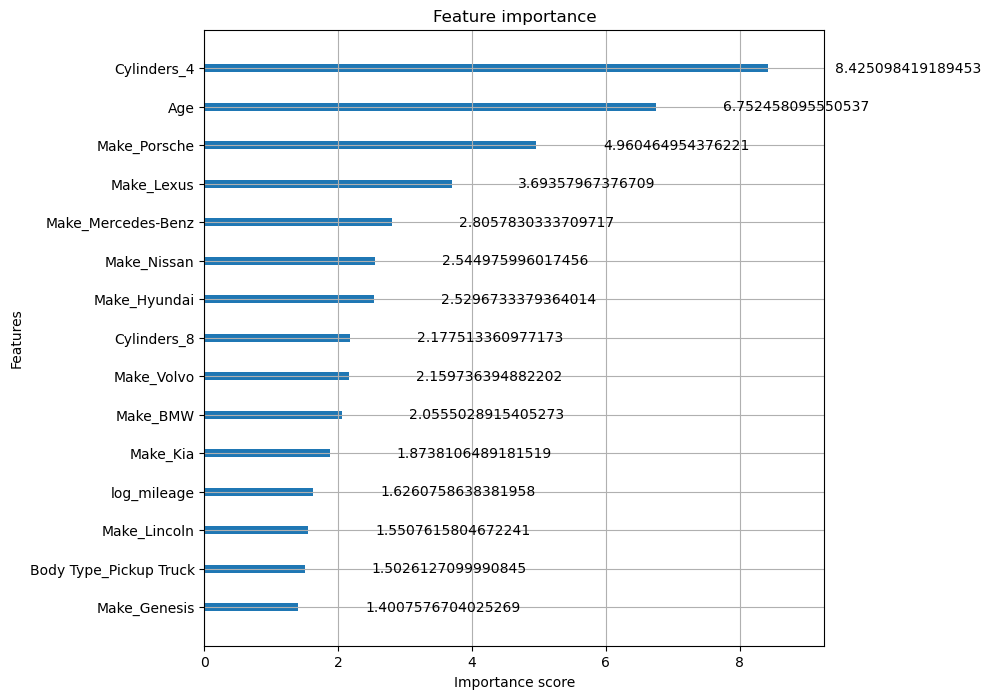

In [36]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)
from xgboost import plot_importance
print(importances)

fig, ax = plt.subplots(figsize=(8, 8))
plot_importance(xgb, importance_type="gain", max_num_features=15, ax=ax)
plt.show()

In [37]:
report = build_prediction_report(
    X_test=X_test,
    y_pred=y_pred,
    lookup_test=lookup_test,
    dummy_prefix_defaults={
        "Cylinders": "baseline_value_here",
        "Body Type": "baseline_value_here",
        "Country_of_Origin": "baseline_value_here",
        "Make":"baseline_value_here"
    },
    log_transformed=True   # set False if you didn't log-transform price
)

report.to_csv("Model OutPut/ModelOutput.csv")

In [38]:
report = build_prediction_report(
    X_test=X_train,
    y_pred=y_train_pred,
    lookup_test=lookup_train,
    dummy_prefix_defaults={
        "Cylinders": "baseline_value_here",
        "Body Type": "baseline_value_here",
        "Country_of_Origin": "baseline_value_here",
        "Make":"baseline_value_here"
    },
    log_transformed=True   # set False if you didn't log-transform price
)
report.to_csv("Model OutPut/ModelInput.csv")

In [39]:
sgbt = GradientBoostingRegressor(
    max_depth=3,
    n_estimators=3000,
    subsample=0.8,
    max_features=0.6,
    learning_rate=0.01,
    random_state=1
)
sgbt.fit(X_train, y_train)
y_pred = sgbt.predict(X_test)
y_train_pred=sgbt.predict(X_train)
results_list.append(returning_Result(y_train,y_train_pred,y_test, y_pred, "GradientBoostingRegressor"))

c:\Users\moham\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [40]:
pd.DataFrame(results_list)

,NameOfModel,MAPE,MAE,MSE,RMSE,R^2,Train_R^2,Train_RMSE,R2_Gap,Status
0,XGBoostRegressor,14.837332,4088.990003,4.544863e+07,6741.559545,0.884357,0.907865,6075.843321,0.023508,Good Fit
1,GradientBoostingRegressor,16.573046,4586.848682,5.455912e+07,7386.414323,0.861176,0.858179,7538.164267,-0.002997,Good Fit


In [41]:
len(X_train.columns)

56

In [42]:
def error_contribution_table(df, features, error_col="abs_error", sort_by="avg_error_vs_overall_pct"):
    total_error = df[error_col].sum()
    overall_avg_error = df[error_col].mean()

    results = []

    for feature in features:
        for value, group in df.groupby(feature):
            group_error_sum = group[error_col].sum()
            group_avg_error = group[error_col].mean()

            results.append({
                "feature": feature,
                "value": value,
                "count": len(group),
                "total_error_share_pct": round(group_error_sum / total_error * 100, 2),
                "avg_error": round(group_avg_error, 2),
                "avg_error_vs_overall_pct": round((group_avg_error - overall_avg_error) / overall_avg_error * 100, 2),
            })

    return pd.DataFrame(results).sort_values(sort_by, ascending=False).reset_index(drop=True)
report["Age_bin"] = pd.qcut(report["Age"], q=10, duplicates="drop")
report["mileage_bin"] = pd.qcut(report["mileage"], q=10, duplicates="drop")
features_to_check = ["Cylinders", "Make", "Body_Type", "Age_bin"]
contribution_table = error_contribution_table(report, features_to_check)
contribution_table

C:\Users\moham\AppData\Local\Temp\ipykernel_35740\1940905283.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for value, group in df.groupby(feature):


,feature,value,count,total_error_share_pct,avg_error,avg_error_vs_overall_pct
0,Cylinders,baseline_value_here,7,0.22,21974.45,496.61
1,Make,Porsche,362,3.76,7347.84,99.49
2,Body_Type,Coupe,569,5.32,6623.51,79.83
3,Cylinders,Electric,876,7.85,6344.86,72.26
4,Make,Tesla,484,4.30,6296.68,70.95
5,Make,Mercedes-Benz,787,6.83,6148.44,66.93
6,Cylinders,8,901,7.72,6069.89,64.80
7,Make,Dodge,515,4.04,5550.09,50.68
8,Make,Volvo,368,2.88,5547.90,50.63
9,Age_bin,"(-0.001, 2.0]",2972,23.11,5508.11,49.54
